<small>This code was made by [Riccardo Campi](https://scholar.google.com/citations?user=JWSoz7EAAAAJ&hl=it), Politecnico di Milano, Data Science Lab.</small>
<br><small>Thanks to [Jean de Dieu Nyandwi](https://github.com/Nyandwi) for inspiring this notebook.</small>

## Library Imports and CSV Loading

We import the necessary libraries for data analysis and visualization, then load the `california housing dataset` dataset from a CSV file.

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
data = pd.read_csv('./datasets/california-housing.csv')

## 4. Missing Values

**Missing values** can arise from various reasons:
- **Measurement Errors**: Data entry mistakes, sensor malfunctions, or other issues during data collection can lead to missing values.
- **Not yet collected**: Some data may not have been collected at the time of analysis.
- **Non-response**: In surveys or questionnaires, some participants may choose not to answer certain questions.
- **Censorship**: In some cases, data may be intentionally withheld or censored due to privacy/legal concerns or ethical considerations.
- **Data Loss**: During data transfer, storage, or processing, some data may be lost due to technical issues.

They can be categorized into three types:
- **MCAR (Missing Completely at Random)**: The missingness is unrelated to any data, observed or unobserved.
  <br>e.g.: survey questions randomly sampled from larger set of possible questions.
- **MAR (Missing at Random)**: The missingness is related to observed data but not to the missing data itself.
  <br>e.g.: respondents with high income less likely to report it.
- **MNAR (Missing Not at Random)**: The missingness is related to the missing data itself.
  <br>e.g.: men less likely than women to respond to question about mental health.

In [2]:
# Print the first few rows of the dataset
data.head() 

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### 4.1 Visualizing Missing Values

We can use visualizations to identify missing values in our dataset.

In [3]:
# Print the number of missing values in each column
data.isna().sum() 

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Let's do a pair plot to visualize the relationships between features and to see if there are any patterns in the missing values.
<br>We can see that the **total bedrooms correlate with total rooms**, and that make sense because the bedrooms are counted in total rooms.

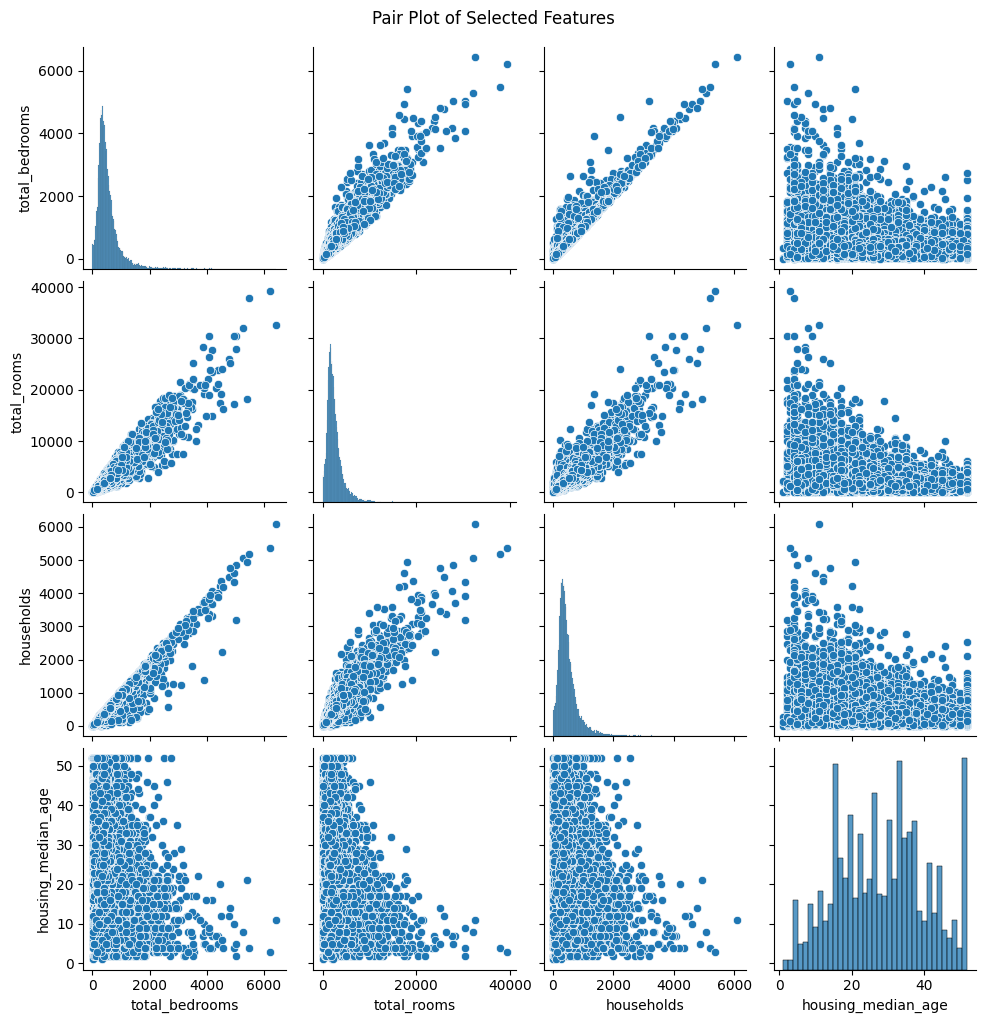

In [4]:
# Plot pairwise relationships between selected features
sns.pairplot(data, vars=['total_bedrooms', 'total_rooms','households','housing_median_age'])
plt.suptitle('Pair Plot of Selected Features', y=1.02)
plt.show()

Now let's plot a histogram of the `total_bedrooms` column to see its distribution.
<br>We can see that **most houses have bedrooms between 0 to 1000**. Very few houses have over 1000 bedrooms.

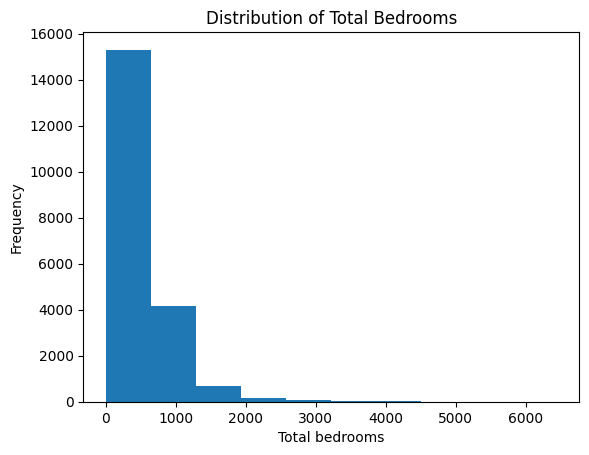

In [5]:
data['total_bedrooms'].plot(kind='hist') # Plot a histogram of the total_bedrooms column
plt.xlabel('Total bedrooms')
plt.ylabel('Frequency')
plt.title('Distribution of Total Bedrooms')
plt.show()

### 4.2 Handling Missing Values

Once we have identified the missing values, we can decide how to handle them. Common strategies include:
- **Deletion**: Removing **rows** or **columns** with missing values.
  <br>This can lead to loss of valuable information and bias if the missingness is not MCAR.
- **Imputation**: Filling in missing values using:
  - **Statistical methods**: mean, median, mode
  - **More advanced techniques**: KNN imputation, regression imputation

Other techniques include:
- **Model-based Methods**: Using algorithms that can handle missing data directly, such as decision trees or certain ensemble methods.
- **Indicator Variables**: Creating binary variables to indicate the presence of missing values, which can be useful in some modeling contexts.

#### 4.2.1 Deletion

Deleting rows or columns with missing values is the most straightforward approach.

##### 4.2.1.1 Deleting Rows with Missing Values

Deleting rows with missing values can be done using the `dropna()` function in pandas.
<br>This method is simple but can lead to significant data loss if many rows have missing values.

In [6]:
# Print the dataset size before dropping missing value rows
print(f"Dataset size before dropping missing value rows: {data.shape}")

# Remove rows with missing values
data_null_rows_dropped=data.copy()
data_null_rows_dropped=data_null_rows_dropped.dropna()

# Print the dataset size after dropping missing values
print(f"Dataset size after dropping missing value rows: {data_null_rows_dropped.shape}")

# Print the number of missing values in each column after dropping rows with missing values
data_null_rows_dropped.isnull().sum()

Dataset size before dropping missing value rows: (20640, 10)
Dataset size after dropping missing value rows: (20433, 10)


longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

##### 4.2.1.2 Deleting Columns with Missing Values

Deleting columns with missing values can also be done using the `dropna()` function in pandas, specifying the `axis` parameter.
<br>This method can lead to loss of important features if the column contains a significant amount of missing values but is still informative.

In [7]:
# Print the dataset size before dropping missing value columns
print(f"Dataset size before dropping missing value columns: {data.shape}")

# Remove columns with missing values
data_null_columns_dropped=data.copy()
data_null_columns_dropped=data_null_columns_dropped.dropna(axis='columns') 

# Print the dataset size after dropping columns with missing values
print(f"Dataset size after dropping missing value columns: {data_null_columns_dropped.shape}")

# Print the number of missing values in each column after dropping columns with missing values
data_null_columns_dropped.isnull().sum()

Dataset size before dropping missing value columns: (20640, 10)
Dataset size after dropping missing value columns: (20640, 9)


longitude             0
latitude              0
housing_median_age    0
total_rooms           0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

It is also possible to delete rows or columns with missing values based on a threshold: we can specify one for the minimum number of non-missing values required to keep a row or column using the `thresh` parameter in the `dropna()` function. 

For example, `data.dropna(thresh=3)` will drop rows that have less than 3 non-missing values. Similarly, `data.dropna(axis=1, thresh=3)` will drop columns that have less than 3 non-missing values.

In [8]:
# Print the dataset size before dropping missing value columns
print(f"Dataset size before dropping missing value columns: {data.shape}")

# Remove columns with missing values
data_null_columns_dropped=data.copy()
data_null_columns_dropped=data_null_columns_dropped.dropna(axis='columns', thresh=200) 

# Print the dataset size after dropping columns with missing values
print(f"Dataset size after dropping missing value columns: {data_null_columns_dropped.shape}")

# Print the number of missing values in each column after dropping columns with missing values
data_null_columns_dropped.isnull().sum()

Dataset size before dropping missing value columns: (20640, 10)
Dataset size after dropping missing value columns: (20640, 10)


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

#### 4.2.2 Imputation

Imputation involves filling in missing values with estimated ones.

##### 4.2.2.1 Simple Imputation (Filling)

Simple imputation methods include filling missing values with the mean, median, or mode of the respective column.
<br>This can be done using the `fillna()` function in pandas.

Let's now fill the missing values in our dataset with a specific value (e.g., 3) and check that there are no missing values after imputation.

In [9]:
# Fill missing values with a specific value (e.g., 3)
data_filled=data.fillna(3)

# Check that there are no missing values after imputation
data_filled.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

Let's now fill the missing values in our dataset with the mean of the respective column for numeric columns and the mode for categorical columns, and check that there are no missing values after imputation.

In [10]:
data_filled = data.copy()

# Fill numeric columns with mean
numeric_cols = data.select_dtypes(include=['number']).columns
data_filled[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].mean())

# Fill categorical columns with mode
categorical_cols = data.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    data_filled[col] = data[col].fillna(data[col].mode()[0])

# Check that there are no missing values after imputation
data_filled.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

The same can be performed using the `SimpleImputer` class from the `sklearn` library, which provides more options for imputation strategies and can be easily integrated into machine learning pipelines.

In [11]:
from sklearn.impute import SimpleImputer

# Simple imputation can be used with numeric data, so we will drop the categorical column for this example
data_numeric=data.drop('ocean_proximity', axis=1) 

# Initialize the SimpleImputer with the desired strategy (e.g., mean)
mean_fill = SimpleImputer(missing_values=np.NaN, strategy='mean')

# Fit the imputer to the numeric data and transform it
mean_fill.fit(data_numeric)
mean_filled = mean_fill.transform(data_numeric)

# Check that there are no missing values after imputation
data_filled.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

#### 4.2.2.2 Iterative Imputation

Iterative imputation methods, such as those implemented in the `IterativeImputer` class from `sklearn`, use a more sophisticated approach to estimate missing values by modeling each feature with missing values as a function of other features in a round-robin fashion.
<br>This can lead to more accurate imputations compared to simple methods, especially when there are complex relationships between features.

In [12]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Initialize the IterativeImputer
iter_imputer = IterativeImputer()

# Fit the imputer to the numeric data and transform it
data_imputed=iter_imputer.fit_transform(data_numeric)
data_imputed_df = pd.DataFrame(data_imputed, columns=data_numeric.columns)

In [13]:
# Print the dataset size before handling missing values
print(f"Dataset size (numerical only) before handling missing values: {data_numeric.shape}")

# Print the dataset size after handling missing values
print(f"Dataset size (numerical only) after handling missing values: {data_imputed_df.shape}")

# Print the number of missing values in each column after handling missing values
data_imputed_df.isnull().sum()

Dataset size (numerical only) before handling missing values: (20640, 9)
Dataset size (numerical only) after handling missing values: (20640, 9)


longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64